In [12]:
!pip install ucimlrepo -q

In [13]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

energy = fetch_ucirepo(id=242)

X = energy.data.features
y = energy.data.targets

df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape: (768, 10)

Columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [14]:
print("=== dtypes ===")
print(df.dtypes)

print("\n=== missing values per column ===")
print(df.isnull().sum())

print("\n=== unique value COUNT per column ===")
print(df.nunique().sort_values())

print("\n=== the discrete-looking features, full value sets ===")
for col in df.columns:
    n = df[col].nunique()
    if n <= 12:
        print(f"{col}  ({n} values): {sorted(df[col].unique())}")

=== dtypes ===
X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X6      int64
X7    float64
X8      int64
Y1    float64
Y2    float64
dtype: object

=== missing values per column ===
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

=== unique value COUNT per column ===
X5      2
X4      4
X6      4
X7      4
X8      6
X3      7
X1     12
X2     12
Y1    586
Y2    636
dtype: int64

=== the discrete-looking features, full value sets ===
X1  (12 values): [np.float64(0.62), np.float64(0.64), np.float64(0.66), np.float64(0.69), np.float64(0.71), np.float64(0.74), np.float64(0.76), np.float64(0.79), np.float64(0.82), np.float64(0.86), np.float64(0.9), np.float64(0.98)]
X2  (12 values): [np.float64(514.5), np.float64(563.5), np.float64(588.0), np.float64(612.5), np.float64(637.0), np.float64(661.5), np.float64(686.0), np.float64(710.5), np.float64(735.0), np.float64(759.5), np.float64(784.0), np.float64(808.5)]
X3  (7 values): 

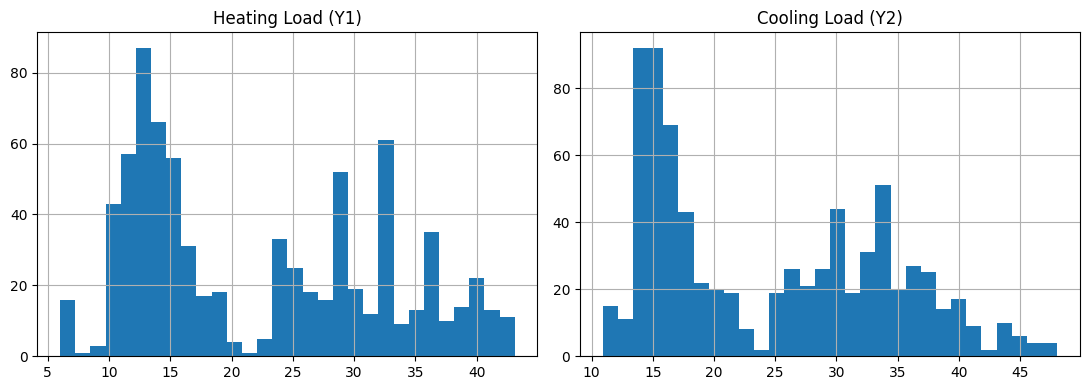

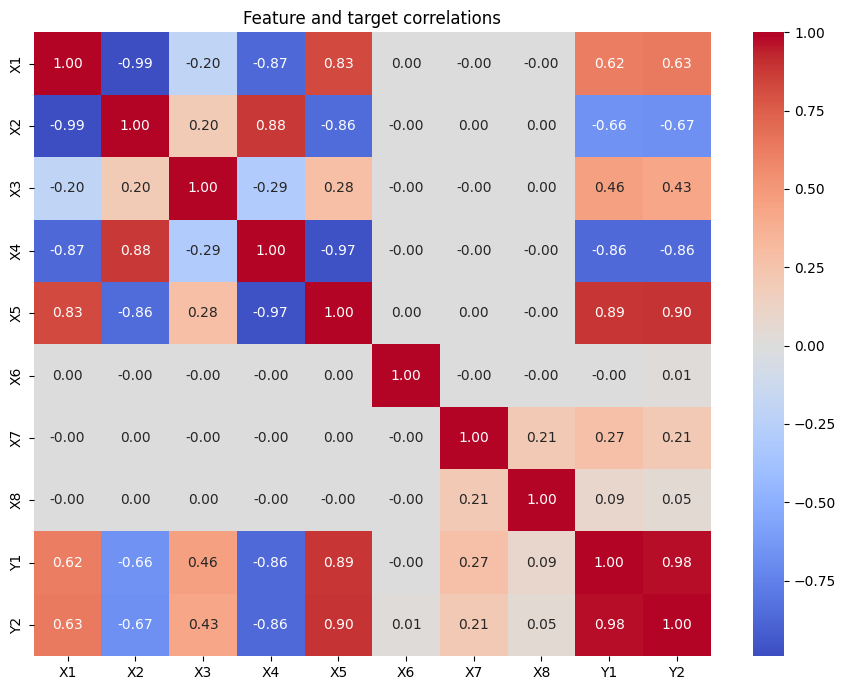

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

df.to_csv("dataset.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["Y1"].hist(ax=ax[0], bins=30); ax[0].set_title("Heating Load (Y1)")
df["Y2"].hist(ax=ax[1], bins=30); ax[1].set_title("Cooling Load (Y2)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature and target correlations")
plt.tight_layout(); plt.show()

In [16]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd

numeric = ["X1", "X2", "X3", "X4", "X5", "X7"]
nominal = ["X6", "X8"]
feats   = numeric + nominal

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), nominal),
])

models = {
    "Linear":           LinearRegression(),
    "Ridge":            Ridge(alpha=1.0),
    "DecisionTree":     DecisionTreeRegressor(random_state=42),
    "RandomForest":     RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

def cv_table(target):
    X, yv = df[feats], df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, yv, test_size=0.2, random_state=42)
    rows = []
    for name, est in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", est)])
        cv = cross_validate(pipe, X_train, y_train, cv=5,
              scoring=["neg_mean_absolute_error",
                       "neg_root_mean_squared_error", "r2"])
        rows.append({
            "model": name,
            "MAE":  -cv["test_neg_mean_absolute_error"].mean(),
            "RMSE": -cv["test_neg_root_mean_squared_error"].mean(),
            "R2":    cv["test_r2"].mean(),
            "R2_std":cv["test_r2"].std(),
        })
    return pd.DataFrame(rows).round(3)

print("HEATING LOAD (Y1)")
print(cv_table("Y1").to_string(index=False))
print("\nCOOLING LOAD (Y2)")
print(cv_table("Y2").to_string(index=False))

HEATING LOAD (Y1)
           model   MAE  RMSE    R2  R2_std
          Linear 2.029 2.827 0.921   0.003
           Ridge 2.034 2.828 0.920   0.003
    DecisionTree 0.388 0.607 0.996   0.001
    RandomForest 0.357 0.539 0.997   0.001
GradientBoosting 0.340 0.488 0.998   0.001

COOLING LOAD (Y2)
           model   MAE  RMSE    R2  R2_std
          Linear 2.309 3.230 0.883   0.007
           Ridge 2.310 3.232 0.883   0.007
    DecisionTree 1.259 2.326 0.939   0.008
    RandomForest 1.073 1.766 0.965   0.007
GradientBoosting 1.045 1.563 0.973   0.002


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators":  [100, 200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth":     [2, 3, 4],
}

splits, best_models = {}, {}
for target in ["Y1", "Y2"]:
    X, yv = df[feats], df[target]
    Xtr, Xte, ytr, yte = train_test_split(X, yv, test_size=0.2, random_state=42)
    splits[target] = (Xtr, Xte, ytr, yte)
    pipe = Pipeline([("prep", preprocessor),
                     ("model", GradientBoostingRegressor(random_state=42))])
    gs = GridSearchCV(pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
    gs.fit(Xtr, ytr)
    best_models[target] = gs.best_estimator_
    print(f"{target}: best params {gs.best_params_}")
    print(f"{target}: best CV R2  {gs.best_score_:.4f}")

Y1: best params {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300}
Y1: best CV R2  0.9984
Y2: best params {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300}
Y2: best CV R2  0.9864


Heating TEST -> MAE 0.280 | RMSE 0.402 | R2 0.998


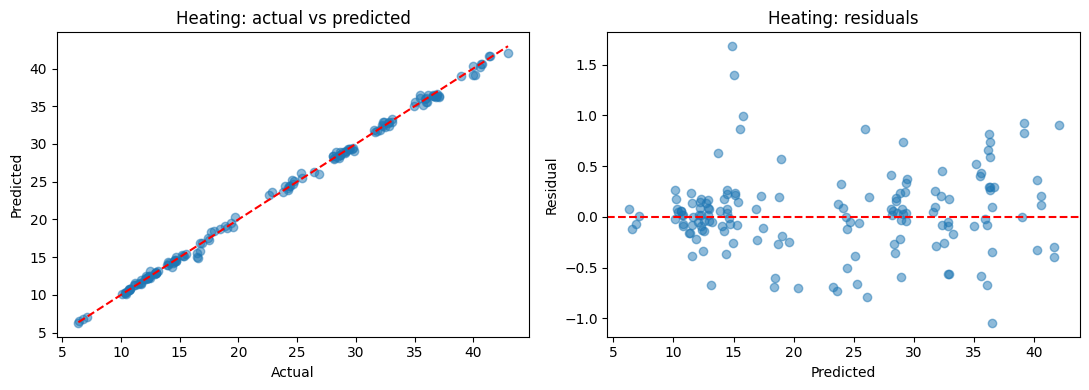

num__X1      0.295
num__X2      0.265
num__X4      0.189
num__X5      0.144
num__X7      0.080
num__X3      0.017
cat__X8_0    0.009
cat__X8_5    0.000 

Cooling TEST -> MAE 0.643 | RMSE 1.193 | R2 0.985


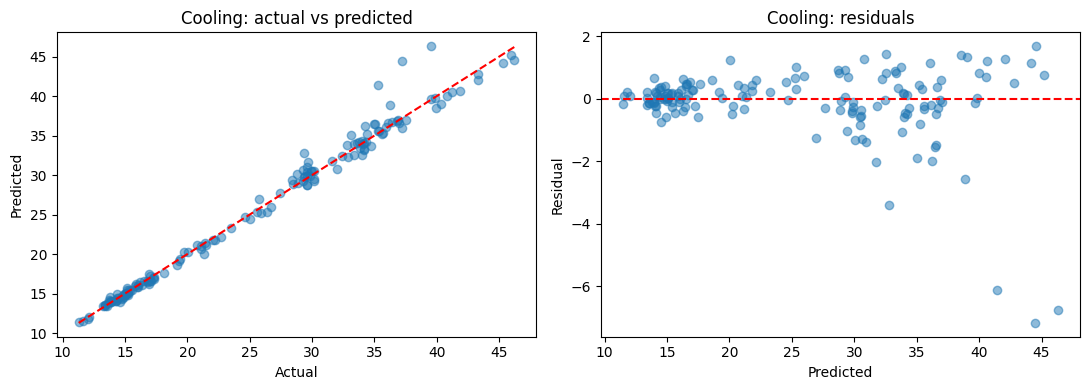

num__X2      0.451
num__X4      0.209
num__X1      0.150
num__X5      0.086
num__X7      0.046
num__X3      0.039
cat__X8_0    0.003
cat__X8_4    0.003 



In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

def diagnose(target, label):
    Xtr, Xte, ytr, yte = splits[target]
    model = best_models[target]
    pred = model.predict(Xte)
    print(f"{label} TEST -> MAE {mean_absolute_error(yte,pred):.3f} | "
          f"RMSE {mean_squared_error(yte,pred)**0.5:.3f} | "
          f"R2 {r2_score(yte,pred):.3f}")
    resid = yte - pred
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].scatter(yte, pred, alpha=0.5)
    ax[0].plot([yte.min(), yte.max()], [yte.min(), yte.max()], "r--")
    ax[0].set(xlabel="Actual", ylabel="Predicted", title=f"{label}: actual vs predicted")
    ax[1].scatter(pred, resid, alpha=0.5); ax[1].axhline(0, color="r", ls="--")
    ax[1].set(xlabel="Predicted", ylabel="Residual", title=f"{label}: residuals")
    plt.tight_layout(); plt.show()
    names = model.named_steps["prep"].get_feature_names_out()
    imp = model.named_steps["model"].feature_importances_
    fi = pd.Series(imp, index=names).sort_values(ascending=False)
    print(fi.head(8).round(3).to_string(), "\n")
    return fi

fi_heating = diagnose("Y1", "Heating")
fi_cooling = diagnose("Y2", "Cooling")

In [19]:
from sklearn.model_selection import cross_validate, GroupKFold

# X1 (relative compactness) uniquely identifies the 12 building shapes,
# so grouping by it holds out WHOLE shapes the model never trained on.
for target, label in [("Y1", "Heating"), ("Y2", "Cooling")]:
    Xtr, Xte, ytr, yte = splits[target]
    groups = df.loc[Xtr.index, "X1"]
    pipe = Pipeline([("prep", preprocessor),
                     ("model", GradientBoostingRegressor(random_state=42))])
    cvg = cross_validate(pipe, Xtr, ytr, groups=groups,
                         cv=GroupKFold(n_splits=5), scoring=["r2"])
    print(f"{label}: shape-held-out R2 = "
          f"{cvg['test_r2'].mean():.3f} (+/- {cvg['test_r2'].std():.3f})")

Heating: shape-held-out R2 = 0.724 (+/- 0.237)
Cooling: shape-held-out R2 = 0.590 (+/- 0.209)


In [20]:
import joblib, sklearn
from sklearn.base import clone

# Refit the tuned pipelines on ALL 768 rows for the deployed model, so it uses
# every configuration. Reported metrics still come from the held-out evaluation
# above; state this clearly in the report.
final_models = {}
for target, key in [("Y1", "heating"), ("Y2", "cooling")]:
    final_models[key] = clone(best_models[target]).fit(df[feats], df[target])

joblib.dump(final_models, "model.pkl")

# Reload-validate: predictions must match the in-memory model
loaded = joblib.load("model.pkl")
sample = df[feats].iloc[[0]]
for key in ["heating", "cooling"]:
    a = final_models[key].predict(sample)[0]
    b = loaded[key].predict(sample)[0]
    print(f"{key}: in-memory {a:.4f} | reloaded {b:.4f} | match {abs(a-b) < 1e-9}")

print("\nPIN THESE in requirements.txt:")
print("scikit-learn ==", sklearn.__version__)
print("joblib       ==", joblib.__version__)

heating: in-memory 15.5505 | reloaded 15.5505 | match True
cooling: in-memory 21.6057 | reloaded 21.6057 | match True

PIN THESE in requirements.txt:
scikit-learn == 1.6.1
joblib       == 1.5.3


In [21]:
from sklearn.model_selection import cross_validate, GroupKFold

groups = df.loc[splits["Y1"][0].index, "X1"]
print("Shape-held-out R2 (heating):")
for name, est in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", est)])
    cvg = cross_validate(pipe, splits["Y1"][0], splits["Y1"][2],
                         groups=groups, cv=GroupKFold(n_splits=5), scoring=["r2"])
    print(f"  {name:16s} {cvg['test_r2'].mean():.3f} (+/- {cvg['test_r2'].std():.3f})")

Shape-held-out R2 (heating):
  Linear           0.770 (+/- 0.101)
  Ridge            0.822 (+/- 0.084)
  DecisionTree     0.673 (+/- 0.285)
  RandomForest     0.718 (+/- 0.268)
  GradientBoosting 0.724 (+/- 0.237)


In [22]:
df[["Y1","Y2"]].describe()

,Y1,Y2
count,768.000000,768.000000
mean,22.307201,24.587760
std,10.090196,9.513306
min,6.010000,10.900000
25%,12.992500,15.620000
50%,18.950000,22.080000
75%,31.667500,33.132500
max,43.100000,48.030000
